# 임베딩 모델 비교 + ChromaDB/FAISS 인덱싱 + QA Chain

1. BGE / E5 / ko-sroberta 세 임베딩 모델로 도메인 문장 유사도 비교
2. `reports_small.json` 또는 `reports.json`을 chunking → ChromaDB 인덱싱
3. 동일 문서셋을 FAISS로도 인덱싱 → 검색 속도/결과 비교
4. LangChain RetrievalQA Chain으로 엔드투엔드 QA 실행


## 0. 환경 설정 및 패키지 설치

In [1]:
# 1) 나눔고딕 폰트 설치
!apt-get -qq update
!apt-get -qq install -y fonts-nanum

# 2) matplotlib 폰트 캐시 갱신
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [2]:
!wget https://raw.githubusercontent.com/ws-l/hh_2026_5/main/data/reports_small.json

--2026-06-22 15:25:25--  https://raw.githubusercontent.com/ws-l/hh_2026_5/main/data/reports_small.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 42666 (42K) [text/plain]
Saving to: ‘reports_small.json.1’

reports_small.json. 100%[===================>]  41.67K  --.-KB/s    in 0.01s   

2026-06-22 15:25:26 (3.61 MB/s) - ‘reports_small.json.1’ saved [42666/42666]



In [3]:
!pip install -q sentence-transformers chromadb faiss-cpu langchain langchain-community langchain-huggingface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 52.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 47.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 75.3 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 43.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━

In [4]:
import json
import time
import numpy as np
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns

with open("reports_small.json", "r", encoding="utf-8") as f:
    reports = json.load(f)

print(f"총 {len(reports)}건 로드")


총 50건 로드


## 1. 임베딩 모델 비교: BGE / E5 / ko-sroberta

같은 문장 쌍에 대해 세 모델이 계산하는 유사도가 얼마나 다른지 비교

In [5]:
embedding_models = {
    "BGE (bge-small-en)": "BAAI/bge-small-en-v1.5",
    "E5 (multilingual-e5-small)": "intfloat/multilingual-e5-small",
    "Ko-sroberta": "jhgan/ko-sroberta-multitask",
}

models = {}
for name, ckpt in embedding_models.items():
    print(f"로드 중: {name}")
    models[name] = SentenceTransformer(ckpt)
print("전체 로드 완료")


로드 중: BGE (bge-small-en)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

전체 로드 완료


In [6]:
# 의미는 같지만 표현이 다른 문장 쌍 (E5는 query/passage prefix 필요)
pair_similar = ("크랭크샤프트 표면에서 마모가 발견되었다", "크랭크샤프트 표면 마모가 관찰됨")
pair_different = ("크랭크샤프트 표면에서 마모가 발견되었다", "포장기 실링 온도가 기준치를 벗어났다")

def get_similarity(model, text1, text2, e5_prefix=False):
    if e5_prefix:
        text1 = "query: " + text1
        text2 = "passage: " + text2
    emb1 = model.encode(text1, normalize_embeddings=True)
    emb2 = model.encode(text2, normalize_embeddings=True)
    return float(np.dot(emb1, emb2))

results = {}
for name, model in models.items():
    is_e5 = "E5" in name
    sim_same = get_similarity(model, *pair_similar, e5_prefix=is_e5)
    sim_diff = get_similarity(model, *pair_different, e5_prefix=is_e5)
    results[name] = {"의미유사 쌍": sim_same, "의미다른 쌍": sim_diff}
    print(f"\n[{name}]")
    print(f"  의미는 같고 표현 다른 문장 쌍 유사도: {sim_same:.4f}")
    print(f"  의미가 다른 문장 쌍 유사도: {sim_diff:.4f}")



[BGE (bge-small-en)]
  의미는 같고 표현 다른 문장 쌍 유사도: 0.9863
  의미가 다른 문장 쌍 유사도: 0.8836

[E5 (multilingual-e5-small)]
  의미는 같고 표현 다른 문장 쌍 유사도: 0.9201
  의미가 다른 문장 쌍 유사도: 0.7852

[Ko-sroberta]
  의미는 같고 표현 다른 문장 쌍 유사도: 0.9577
  의미가 다른 문장 쌍 유사도: 0.4780


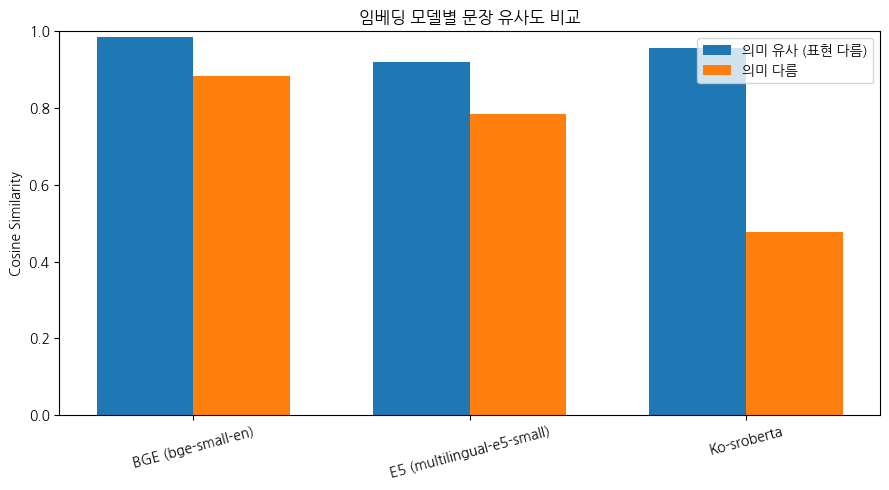

In [7]:
# 막대그래프로 비교
labels = list(results.keys())
sim_same_vals = [results[k]["의미유사 쌍"] for k in labels]
sim_diff_vals = [results[k]["의미다른 쌍"] for k in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, sim_same_vals, width, label="의미 유사 (표현 다름)")
ax.bar(x + width/2, sim_diff_vals, width, label="의미 다름")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel("Cosine Similarity")
ax.set_title("임베딩 모델별 문장 유사도 비교")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


**관찰 포인트**
- 좋은 임베딩 모델일수록 "의미 유사 쌍"과 "의미 다른 쌍"의 유사도 격차(gap)가 커야 함
- 한국어 전문용어가 많은 도메인에서는 ko-sroberta가 상대적으로 안정적인 경향을 보일 수 있음
- E5는 query/passage prefix를 빼먹으면 성능이 떨어지므로 반드시 적용


## 2. Chunking + ChromaDB 인덱싱

`reports.json`의 서술형 보고서를 chunk 단위로 분할하고 ChromaDB에 적재


In [8]:
import chromadb
from chromadb.utils import embedding_functions

# 임베딩 함수로 ko-sroberta 사용 (한국어 도메인에 적합, 한국어 의미 벡터화)
ko_sroberta_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="jhgan/ko-sroberta-multitask"
)

#chroma db 방식으로 임베딩: langchain과 차이    
chroma_client = chromadb.Client()
collection = chroma_client.get_or_create_collection(
    name="engine_defect_reports",
    embedding_function=ko_sroberta_ef,
)

print("Collection 생성 완료:", collection.name)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Collection 생성 완료: engine_defect_reports


In [9]:
# 보고서는 비교적 짧으므로(250~400자) 별도 chunking 없이 1건=1chunk로 인덱싱
# 문서가 더 길어지는 실제 환경에서는 RecursiveCharacterTextSplitter 등으로 chunk 분할 필요

documents = [r["report_text"] for r in reports]
ids = [r["report_id"] for r in reports]
metadatas = [
    {
        "설비종류": r.get("설비종류", ""),
        "불량유형": r.get("불량유형", ""),
        "4M_분류": r.get("4M_분류", ""),
        "심각도": r.get("심각도", ""),
    }
    for r in reports
]

collection.add(documents=documents, ids=ids, metadatas=metadatas)
print(f"{collection.count()}건 인덱싱 완료")


50건 인덱싱 완료


In [10]:
# 검색 테스트
query = "크랭크샤프트에서 크랙이 발생한 사례"
results = collection.query(query_texts=[query], n_results=3)

for i, (doc, meta, dist) in enumerate(zip(
    results["documents"][0], results["metadatas"][0], results["distances"][0]
)):
    print(f"\n[{i+1}] 거리: {dist:.4f} | 설비종류: {meta['설비종류']} | 불량유형: {meta['불량유형']}")
    print(doc[:150])



[1] 거리: 0.2953 | 설비종류: CNC 머신 | 불량유형: 표면결함-스크래치/크랙
2024년 2월 28일 16:50, CNC 머신 F-1호기에서 알루미늄 판재 상면에 원형 공구 자국과 미세 스크래치가 혼재되어 발생함을 확인함. 절삭유 압력은 정상 0.35MPa 대비 0.18MPa로 낮았고 절삭온도는 174°C까지 상승하여 설비보전팀에서 심각도 상으로

[2] 거리: 0.3129 | 설비종류: CNC 머신 | 불량유형: 표면결함-스크래치/크랙
2024년 1월 5일 14:30, CNC 머신 A-2호기에서 스테인리스 커버 외곽 절삭면에 길이 18~25mm의 미세 스크래치가 관찰됨. 절삭온도는 165°C까지 상승했고 공구 측면 마모량은 0.46mm로 확인되어 CNC가공팀에서 중등도 결함으로 기록함. 원인은 마모된

[3] 거리: 0.3133 | 설비종류: CNC 머신 | 불량유형: 표면결함-스크래치/크랙
2024년 1월 18일 11:05, CNC 머신 B-2호기에서 가공품 측면에 폭 0.15~0.22mm의 선형 스크래치가 반복 발생함을 확인함. 칩 배출 컨베이어 지연으로 절삭 칩이 지그 주변에 잔류했고 절삭온도는 138°C로 기록되어 설비보전팀에서 심각도 중으로 접수함


In [11]:
# metadata 필터링 검색 - 특정 설비종류로 한정
query2 = "표면에서 결함이 발견된 사례"
results2 = collection.query(
    query_texts=[query2],
    n_results=3,
    where={"설비종류": "CNC 가공기-실린더블록용"},
)

print(f"필터링된 검색 결과: {len(results2['documents'][0])}건")
for doc in results2["documents"][0]:
    print("-", doc[:100])


필터링된 검색 결과: 0건


## 3. FAISS 인덱싱 + ChromaDB와 속도/결과 비교


In [12]:
import faiss

# ko-sroberta로 전체 문서 임베딩 생성
ko_model = models["Ko-sroberta"]
doc_embeddings = ko_model.encode(documents, normalize_embeddings=True, show_progress_bar=True)  #768차원으로 직접 임베딩
doc_embeddings = np.array(doc_embeddings).astype("float32")

dim = doc_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(dim)  # 정규화된 임베딩이므로 Inner Product = Cosine Similarity
faiss_index.add(doc_embeddings)

print(f"FAISS 인덱스 구성 완료: {faiss_index.ntotal}건, 차원={dim}")


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

FAISS 인덱스 구성 완료: 50건, 차원=768


In [13]:
def faiss_search(query, k=3):
    query_emb = ko_model.encode([query], normalize_embeddings=True).astype("float32")
    scores, indices = faiss_index.search(query_emb, k)
    return [(documents[idx], scores[0][i], ids[idx]) for i, idx in enumerate(indices[0])]

# 검색 속도 비교
query = "크랭크샤프트에서 크랙이 발생한 사례"

start = time.time()
chroma_results = collection.query(query_texts=[query], n_results=3)
chroma_time = time.time() - start

start = time.time()
faiss_results = faiss_search(query, k=3)
faiss_time = time.time() - start

print(f"ChromaDB 검색 시간: {chroma_time*1000:.2f}ms")
print(f"FAISS 검색 시간: {faiss_time*1000:.2f}ms")
print()
print("=== FAISS 검색 결과 ===")
for doc, score, doc_id in faiss_results:
    print(f"[{doc_id}] score={score:.4f}: {doc[:100]}")


ChromaDB 검색 시간: 113.04ms
FAISS 검색 시간: 159.47ms

=== FAISS 검색 결과 ===
[RPT-020] score=0.7047: 2024년 2월 28일 16:50, CNC 머신 F-1호기에서 알루미늄 판재 상면에 원형 공구 자국과 미세 스크래치가 혼재되어 발생함을 확인함. 절삭유 압력은 정상 0.35MPa 
[RPT-002] score=0.6871: 2024년 1월 5일 14:30, CNC 머신 A-2호기에서 스테인리스 커버 외곽 절삭면에 길이 18~25mm의 미세 스크래치가 관찰됨. 절삭온도는 165°C까지 상승했고 공구 측
[RPT-007] score=0.6867: 2024년 1월 18일 11:05, CNC 머신 B-2호기에서 가공품 측면에 폭 0.15~0.22mm의 선형 스크래치가 반복 발생함을 확인함. 칩 배출 컨베이어 지연으로 절삭 칩이


**관찰 포인트**
- 문서 수가 적은 PoC 단계에서는 ChromaDB/FAISS 속도 차이가 크지 않음
- ChromaDB는 metadata 필터링이 내장되어 있어 운영 편의성이 높음
- FAISS는 순수 검색 속도에 최적화되어 있어 대규모 문서셋(수만 건 이상)에서 강점


## 4. LangChain RetrievalQA Chain 구성

ChromaDB를 LangChain의 vector store로 연결하고, QA Chain을 통해 엔드투엔드로 질의응답

ko-sroberta: 한국어 문장 간 의미 유사도에 특화되어 있어서, 검색 품질이 좋음

In [14]:
from langchain_community.vectorstores import Chroma as LC_Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_classic.chains import RetrievalQA  
from langchain_huggingface import HuggingFacePipeline
from transformers import pipeline

# LangChain용 임베딩 래퍼, langchain 전용 규격
lc_embeddings = HuggingFaceEmbeddings(model_name="jhgan/ko-sroberta-multitask")

# Document 객체로 변환
lc_documents = [
    Document(page_content=r["report_text"], metadata={"report_id": r["report_id"]})
    for r in reports
]

# LangChain 전용 별도 컬렉션으로 vector store 구성
lc_vectorstore = LC_Chroma.from_documents(
    documents=lc_documents,
    embedding=lc_embeddings,
    collection_name="lc_engine_reports",
)

retriever = lc_vectorstore.as_retriever(search_kwargs={"k": 3})
print("LangChain vector store 구성 완료")


/tmp/ipykernel_3280/1698427841.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import Chroma as LC_Chroma


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

LangChain vector store 구성 완료


In [15]:
# 가벼운 한국어 생성 모델을 LLM으로 임시 연결 ( Ollama로 교체 예정)
gen_pipeline = pipeline(
    "text-generation",
    model="skt/kogpt2-base-v2",
    max_new_tokens=80,
    temperature=0.3,
    do_sample=True,
)
llm = HuggingFacePipeline(pipeline=gen_pipeline)

qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=retriever,
    return_source_documents=True,
)

print("QA Chain 구성 완료")


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


QA Chain 구성 완료


In [16]:
question = "크랭크샤프트 관련 불량 사례의 원인은 보통 무엇인가요?"
response = qa_chain.invoke({"query": question})

print("=== 답변 ===")
print(response["result"])
print()
print("=== 참고한 출처 문서 ===")
for doc in response["source_documents"]:
    print("-", doc.metadata["report_id"], ":", doc.page_content[:80])


[transformers] Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


=== 답변 ===
Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer.

2024년 4월 7일 10:10, 컨베이어 벨트 3라인에서 플라스틱 커버 이송 후 외관면에 길이 15~28mm의 선형 스크래치가 발생한 것을 확인함. 이송속도는 2.4m/s였으며 공급 자재 박스 내부 완충지가 누락된 묶음에서 결함이 집중되어 품질관리팀에서 심각도 하로 분류함. 보관 및 운반 중 완충 포장이 누락된 원자재가 컨베이어 진입 전 이미 손상된 것으로 판단됨. 완충지 누락 자재를 격리하고 외관 선별을 실시했으며 공급업체에 포장 상태 개선과 재발 방지 보고서를 요청함. 입고 시 완충 포장 누락 여부를 샘플링 검사 항목에 추가함.

2024년 4월 22일 15:15, 컨베이어 벨트 8라인에서 냉각수 테스트 완료품 이송 중 커넥터 부위에서 0.4~0.7mL/min 수준의 누설을 확인함. 사용된 O-링 경도는 표준 70 Shore A 대비 58 Shore A로 낮게 측정되어 품질관리팀에서 심각도 중으로 접수함. 규격보다 연질인 O-링이 압착 후 복원력을 유지하지 못해 커넥터 밀봉이 불완전했던 것으로 판단됨. 해당 O-링 로트를 격리하고 표준 경도 제품으로 교체했으며 누설 발생품은 재조립 후 압력 테스트를 재수행함. O-링 입고 시 경도와 치수 검사를 동시에 실시함.

2024년 2월 28일 16:50, CNC 머신 F-1호기에서 알루미늄 판재 상면에 원형 공구 자국과 미세 스크래치가 혼재되어 발생함을 확인함. 절삭유 압력은 정상 0.35MPa 대비 0.18MPa로 낮았고 절삭온도는 174°C까지 상승하여 설비보전팀에서 심각도 상으로 접수함. 절삭유 펌프 임펠러 마모로 냉각과 칩 제거가 부족해 표면 손상이 발생한 것으로 추정됨. 절삭유 펌프 임펠러를 교체

**관찰 포인트**
- retriever가 가져온 context가 답변 품질에 직접 영향을 미침을 확인
- 경량 생성 모델(kogpt2)의 한계로 답변 품질이 다소 부족할 수 있음 — Ollama의 더 큰 모델로 교체 시 개선 효과를 비교할 예정
- `chain_type="stuff"`는 모든 검색 결과를 한 번에 prompt에 넣는 방식. 문서가 많아지면 map_reduce/refine 방식 고려 필요
